## What is ML?
It is predicting a future outcome from the past or historic data. When we plot our data, there will be line that seperated our data into two f=defferent sets. Our machine has to predict that accurately. That will help us to predict the future outcome. This line is Y=MX+C in algebra.

# Exploratory Data Analysis (EDA) with Iris Dataset
### A Complete Guide to Data Exploration and Visualization

> **Prerequisites:** Basic Python, Pandas  
> **Duration:** ~2.5 hours  
> **Dataset:** Iris Dataset  
> **Libraries:** Pandas, Matplotlib, Seaborn, Plotly

---

## 1. Basic Terminology in Data Science

Before we dive into data analysis, let's understand the key terms you'll encounter.

### What is EDA (Exploratory Data Analysis)?

**EDA** is the process of analyzing datasets to summarize their main characteristics, often using visual methods. It helps you:
- Understand the data structure
- Detect outliers and anomalies
- Discover patterns and relationships
- Test assumptions
- Generate hypotheses

Think of EDA as "getting to know your data" before building models.

### Key Terms Explained

#### 1. Feature / Variable / Column
**Definition:** A measurable property or characteristic of the data.

**Example:** In the Iris dataset:
- `sepal_length` is a feature
- `petal_width` is a feature
- `species` is a feature

**Analogy:** If data is a spreadsheet, features are the column headers.

---

#### 2. Input Variable / Independent Variable / Predictor
**Definition:** Variables used to predict or explain the output.

**Example:**
- `sepal_length`, `sepal_width`, `petal_length`, `petal_width` are input variables
- We use these to predict the species

**Symbol:** Often denoted as **X** or **x**

**Analogy:** These are the "ingredients" you use to make a prediction.

---

#### 3. Output Variable / Dependent Variable / Target / Response / Label / Class Label
**Definition:** The variable we want to predict or explain.

**Example:**
- `species` is the output variable
- It depends on the input features

**Symbol:** Often denoted as **y** or **Y**

**Analogy:** This is the "result" or "answer" you're trying to predict.

---

#### 4. Class / Category
**Definition:** A distinct group or category in classification problems.

**Example:** In Iris dataset, there are 3 classes:
- Setosa
- Versicolor  
- Virginica

**Note:** Used in classification problems (predicting categories).

---

#### 5. Observation / Sample / Instance / Row / Data Point
**Definition:** A single record or example in your dataset.

**Example:** One flower with its measurements is one observation:
```
sepal_length=5.1, sepal_width=3.5, petal_length=1.4, petal_width=0.2, species=setosa
```

**Analogy:** If data is a spreadsheet, an observation is one row.

### Understanding Dimensions: Vectors and Spaces

#### What is a Vector?

A **vector** is an ordered list of numbers. In data science, each observation can be represented as a vector.

**Example from Iris:**
```
Flower 1: [5.1, 3.5, 1.4, 0.2]  ← This is a 4D vector
          ↑    ↑    ↑    ↑
          |    |    |    └─ petal_width
          |    |    └────── petal_length
          |    └─────────── sepal_width
          └──────────────── sepal_length
```

---

#### Dimensions Explained

**1D (One-Dimensional):**
- A single number or a line
- Example: `[5.1]` (just sepal length)
- Visualization: A number line

**2D (Two-Dimensional):**
- Two numbers, like coordinates on a plane
- Example: `[5.1, 3.5]` (sepal length and width)
- Visualization: Scatter plot (X-Y plane)

**3D (Three-Dimensional):**
- Three numbers, like coordinates in space
- Example: `[5.1, 3.5, 1.4]` (sepal length, width, petal length)
- Visualization: 3D scatter plot

**4D (Four-Dimensional):**
- Four numbers
- Example: `[5.1, 3.5, 1.4, 0.2]` (all 4 Iris features)
- Visualization: Can't visualize directly! Use techniques like:
  - Color coding (3D + color for 4th dimension)
  - Size coding (3D + size for 4th dimension)
  - Multiple 2D/3D plots
  - Dimensionality reduction (PCA, t-SNE)

**nD (n-Dimensional):**
- n numbers (where n can be any positive integer)
- Example: A dataset with 100 features is 100-dimensional
- Visualization: Requires advanced techniques

**Key Insight:** Humans can only visualize up to 3D directly. For higher dimensions, we use creative techniques!

---

## 2. The Iris Flower Dataset

### What is the Iris Dataset?

The Iris dataset contains measurements of 150 iris flowers from 3 different species. It's one of the most famous datasets in machine learning and statistics.

### The Flowers

**Species 1: Iris Setosa**
- Small petals
- Very distinctive
- Easy to identify

**Species 2: Iris Versicolor**
- Medium-sized petals
- Intermediate features
- Some overlap with Virginica

**Species 3: Iris Virginica**
- Large petals
- Similar to Versicolor
- Harder to distinguish

### The Measurements

Each flower has 4 measurements (in centimeters):

1. **Sepal Length** - Length of the protective outer leaf
2. **Sepal Width** - Width of the protective outer leaf
3. **Petal Length** - Length of the colorful inner petal
4. **Petal Width** - Width of the colorful inner petal

**Visual Guide:**
```
     Sepal (outer)
    ┌─────────────┐
    │             │
    │   Petal     │
    │  (inner)    │
    │   ┌─────┐   │
    │   │     │   │
    │   └─────┘   │
    │             │
    └─────────────┘
```

### Dataset Structure

- **150 observations** (flowers)
- **5 columns** (4 features + 1 target)
- **3 classes** (species)
- **50 samples per class** (balanced dataset)

---

## 3. Loading and Exploring the Data

Let's load the Iris dataset and explore its basic properties.

In [3]:
pip install plotly

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ----------------- ---------------------- 4.5/9.9 MB 27.5 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.9 MB 28.4 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 24.5 MB/s  0:00:00

   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narw

In [5]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as pxx
import plotly.graph_objects as go

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Load the Iris dataset
iris = sns.load_dataset('iris')

print("Dataset loaded successfully!")
print(f"Type: {type(iris)}")

Dataset loaded successfully!
Type: <class 'pandas.DataFrame'>


### 3.1 — First Look: head()

The `head()` method shows the first few rows of the dataset.

In [2]:
# Display first 5 rows
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
# Display first 10 rows
iris.head(10)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


### 3.2 — Last Look: tail()

The `tail()` method shows the last few rows of the dataset.

In [3]:
# Display last 5 rows
iris.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [ ]:
# Display last 8 rows
iris.tail(8)

,sepal_length,sepal_width,petal_length,petal_width,species
142,5.8,2.7,5.1,1.9,virginica
143,6.8,3.2,5.9,2.3,virginica
144,6.7,3.3,5.7,2.5,virginica
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


### 3.3 — Dataset Shape

The `shape` attribute tells us the dimensions of the dataset: (rows, columns)

In [4]:
# Get the shape
print(f"Shape: {iris.shape}")
print(f"Number of rows (observations): {iris.shape[0]}")
print(f"Number of columns (features): {iris.shape[1]}")

Shape: (150, 5)
Number of rows (observations): 150
Number of columns (features): 5


**Interpretation:**
- 150 rows = 150 flowers (observations)
- 5 columns = 4 measurements + 1 species label (features)

### 3.4 — Dataset Info

The `info()` method provides a concise summary of the dataset.

In [5]:
# Get dataset information
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


**What info() tells us:**
- Column names
- Number of non-null values (no missing data!)
- Data types (float64 for measurements, object for species)
- Memory usage

### 3.5 — Column Names

Get the list of all column names.

In [6]:
# Get column names
print("Column names:")
print(iris.columns.tolist())

Column names:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


### 3.6 — Data Types

Check the data type of each column.

In [7]:
# Get data types
print("Data types:")
print(iris.dtypes)

Data types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


### 3.7 — Statistical Summary

The `describe()` method provides statistical summary of numerical columns.

In [ ]:
# Statistical summary
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


**What describe() shows:**
- **count:** Number of non-null values
- **mean:** Average value
- **std:** Standard deviation (spread)
- **min:** Minimum value
- **25%:** First quartile (Q1)
- **50%:** Median (Q2)
- **75%:** Third quartile (Q3)
- **max:** Maximum value

### 3.8 — Value Counts

Count the number of observations for each species.

In [8]:
# Count by species
print("Species distribution:")
print(iris['species'].value_counts())

Species distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [ ]:
# With percentages
print("\nSpecies distribution (percentages):")
print(iris['species'].value_counts(normalize=True) * 100)


Species distribution (percentages):
species
setosa        33.333333
versicolor    33.333333
virginica     33.333333
Name: proportion, dtype: float64


**Observation:** The dataset is perfectly balanced - 50 flowers of each species (33.33% each).

### 3.9 — Unique Values

Check unique values in the species column.

In [9]:
# Unique species
print("Unique species:")
print(iris['species'].unique())
print(f"\nNumber of unique species: {iris['species'].nunique()}")

Unique species:
['setosa' 'versicolor' 'virginica']

Number of unique species: 3


### 3.10 — Missing Values Check

Check if there are any missing values in the dataset.

In [10]:
# Check for missing values
print("Missing values per column:")
print(iris.isnull().sum())
print(f"\nTotal missing values: {iris.isnull().sum().sum()}")

Missing values per column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Total missing values: 0


**Great news!** No missing values in this dataset. 🎉

---

## 4. 2D Scatter Plots

### What is a Scatter Plot?

A **scatter plot** displays the relationship between two numerical variables. Each point represents one observation.

**Use cases:**
- Identify correlations (positive, negative, or none)
- Detect clusters or groups
- Spot outliers
- Visualize relationships

### 4.1 — Basic Scatter Plot (Pandas)

Let's start with the simplest approach using Pandas built-in plotting.

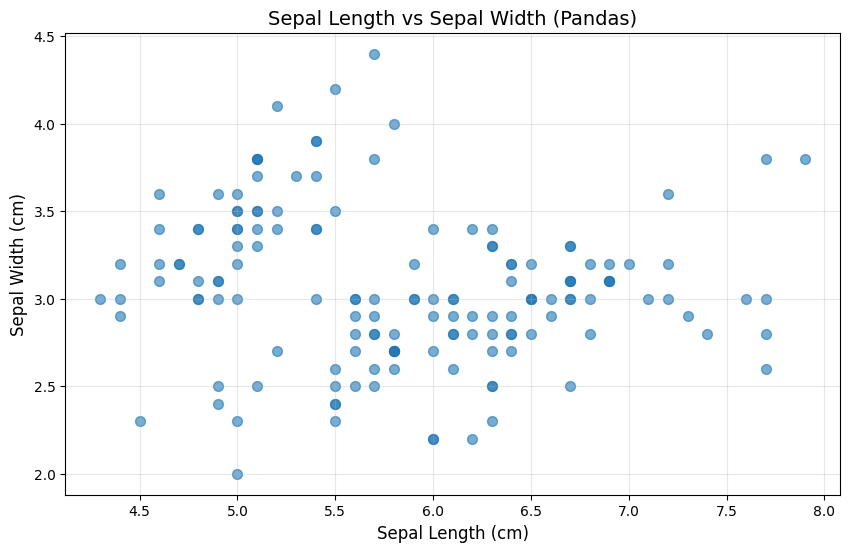

In [13]:
# Simple scatter plot using Pandas
iris.plot(kind='scatter', x='sepal_length', y='sepal_width',
          figsize=(10, 6), alpha=0.6, s=50)
plt.title('Sepal Length vs Sepal Width (Pandas)', fontsize=14)
plt.xlabel('Sepal Length (cm)', fontsize=12)
plt.ylabel('Sepal Width (cm)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

**Observation:** We can see the data points, but we can't distinguish between species yet.

### 4.2 — Scatter Plot with Species Colors (Matplotlib)

Now let's color-code the points by species to see patterns.

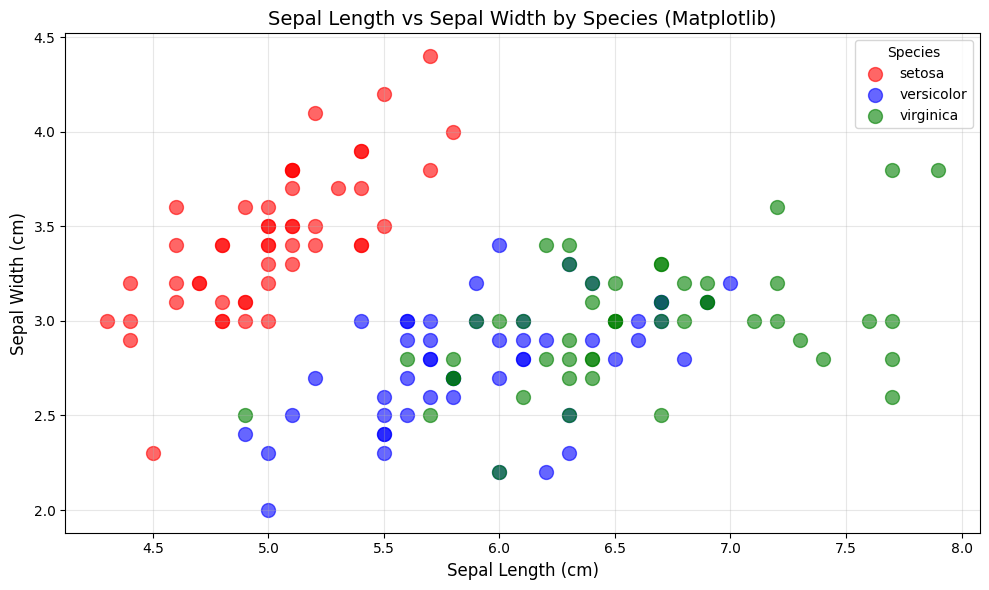

In [ ]:
# Scatter plot with species colors using Matplotlib
plt.figure(figsize=(10, 6))

# Plot each species separately
colors = {'setosa': 'red', 'versicolor': 'blue', 'virginica': 'green'}

for species in iris['species'].unique():
    subset = iris[iris['species'] == species]
    plt.scatter(subset['sepal_length'], subset['sepal_width'],
                label=species, alpha=0.6, s=100, c=colors[species])

plt.xlabel('Sepal Length (cm)', fontsize=12)
plt.ylabel('Sepal Width (cm)', fontsize=12)
plt.title('Sepal Length vs Sepal Width by Species (Matplotlib)', fontsize=14)
plt.legend(title='Species', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:**
- Setosa (red) is clearly separated from the other two species
- Versicolor (blue) and Virginica (green) have some overlap
- Setosa tends to have shorter sepals but wider sepals

### 4.3 — Scatter Plot with Seaborn

Seaborn makes it even easier with better default styling.

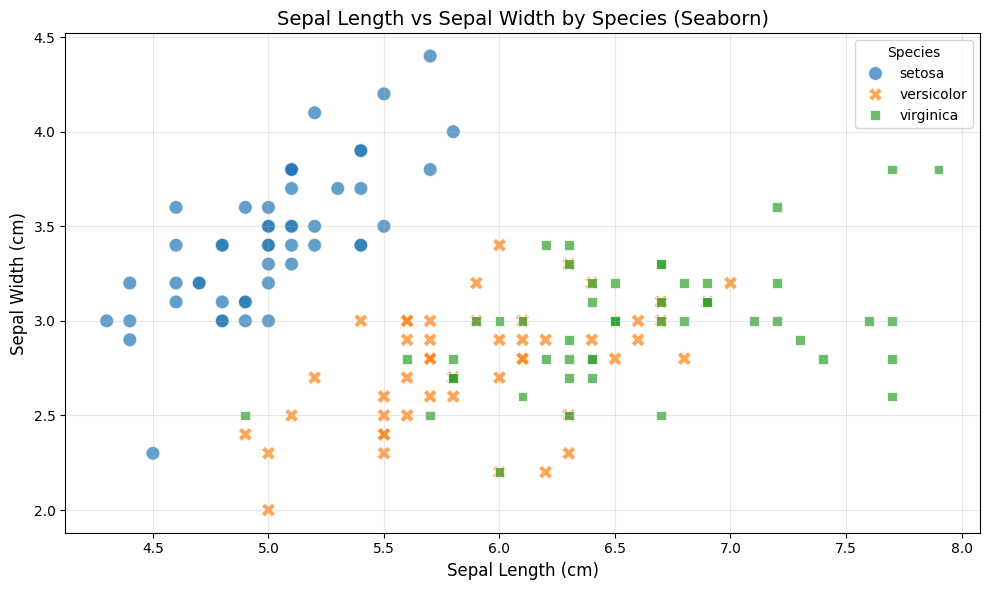

In [ ]:
# Scatter plot using Seaborn
plt.figure(figsize=(10, 6))

sns.scatterplot(data=iris, x='sepal_length', y='sepal_width',
                hue='species', style='species', s=100, alpha=0.7)

plt.xlabel('Sepal Length (cm)', fontsize=12)
plt.ylabel('Sepal Width (cm)', fontsize=12)
plt.title('Sepal Length vs Sepal Width by Species (Seaborn)', fontsize=14)
plt.legend(title='Species', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Seaborn advantages:**
- Automatic color palette
- Different markers for each species
- Cleaner default styling
- Less code!

### 4.4 — Interactive Scatter Plot with Plotly

Plotly adds interactivity - hover, zoom, pan!

In [14]:
# Interactive scatter plot using Plotly
fig = px.scatter(iris, x='sepal_length', y='sepal_width',
                 color='species',
                 title='Sepal Length vs Sepal Width by Species (Plotly - Interactive!)',
                 labels={'sepal_length': 'Sepal Length (cm)',
                         'sepal_width': 'Sepal Width (cm)'},
                 width=900, height=600)

fig.update_traces(marker=dict(size=10, opacity=0.7))
fig.show()

**Plotly advantages:**
- **Hover** over points to see exact values
- **Zoom** in/out with scroll wheel
- **Pan** by clicking and dragging
- **Click legend** to hide/show species
- **Double-click** to reset view

Try interacting with the plot above!

### 4.5 — Comparing Different Feature Pairs

Let's explore other feature combinations.

In [15]:
# Petal Length vs Petal Width
fig = px.scatter(iris, x='petal_length', y='petal_width',
                 color='species',
                 title='Petal Length vs Petal Width by Species',
                 labels={'petal_length': 'Petal Length (cm)',
                         'petal_width': 'Petal Width (cm)'},
                 width=900, height=600)

fig.update_traces(marker=dict(size=10, opacity=0.7))
fig.show()

**Observation:** Petal measurements separate species MUCH better than sepal measurements!
- Setosa has very small petals
- Clear linear relationship between petal length and width
- Virginica has the largest petals

---

## 5. 3D Scatter Plots

### Moving to Three Dimensions

With 2D plots, we can only visualize 2 features at a time. What if we want to see 3 features simultaneously?

**Enter 3D scatter plots!**

In [16]:
# 3D scatter plot using Plotly
fig = px.scatter_3d(iris,
                    x='sepal_length',
                    y='sepal_width',
                    z='petal_length',
                    color='species',
                    title='3D View: Sepal Length, Sepal Width, and Petal Length',
                    labels={'sepal_length': 'Sepal Length (cm)',
                            'sepal_width': 'Sepal Width (cm)',
                            'petal_length': 'Petal Length (cm)'},
                    width=900, height=700)

fig.update_traces(marker=dict(size=5, opacity=0.8))
fig.show()

**How to interact with 3D plot:**
- **Click and drag** to rotate the view
- **Scroll** to zoom in/out
- **Right-click and drag** to pan
- **Hover** over points for details

**Observation:** The 3D view shows even better separation between species!

**3. For 5D, 6D, ...nD:**

When you have many dimensions (features), direct visualization becomes impossible. Instead, use:

**Dimensionality Reduction Techniques:**
- **PCA (Principal Component Analysis)** - Reduces dimensions while preserving variance
- **t-SNE** - Visualizes high-dimensional data in 2D/3D
- **UMAP** - Similar to t-SNE but faster

**Multiple Plots:**
- **Pair plots** - Show all 2D combinations
- **Parallel coordinates** - Show all dimensions as parallel axes
- **Heatmaps** - Show correlations between features

**Key Insight:** Humans can only visualize 3D directly. For higher dimensions, we need creative techniques or dimensionality reduction!

---

## 6. Pair Plots (Scatter Matrix)

### The Problem

We have 4 features in the Iris dataset. To see all relationships, we'd need to create many individual scatter plots:
- Sepal Length vs Sepal Width
- Sepal Length vs Petal Length
- Sepal Length vs Petal Width
- Sepal Width vs Petal Length
- ... and so on

**How many combinations are there?**

### Calculating Possible Combinations

For **n features**, the number of unique 2D scatter plots is:

**Formula:** C(n, 2) = n × (n - 1) / 2

Where C(n, 2) means "choose 2 from n"

**For Iris (n = 4):**
- C(4, 2) = 4 × 3 / 2 = **6 unique pairs**

**The 6 combinations:**
1. Sepal Length vs Sepal Width
2. Sepal Length vs Petal Length
3. Sepal Length vs Petal Width
4. Sepal Width vs Petal Length
5. Sepal Width vs Petal Width
6. Petal Length vs Petal Width

**Plus:** We can add histograms on the diagonal to show distributions of each feature.

**Total plots in pair plot:** 4 × 4 = 16 plots (including diagonal)

### What is a Pair Plot?

A **pair plot** (also called scatter matrix) shows:
- **Off-diagonal:** Scatter plots for all feature pairs
- **Diagonal:** Distribution of each feature (histogram or KDE)

It's a powerful tool to see all relationships at once!

### 6.1 — Pair Plot with Matplotlib

Let's create a basic pair plot using Pandas and Matplotlib.

/var/folders/jw/7pnq01ns5fdbp2gbkfz_n6sm0000gn/T/ipykernel_47792/2086164359.py:7: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  scatter_matrix(iris.iloc[:, :4],  # Only numerical columns


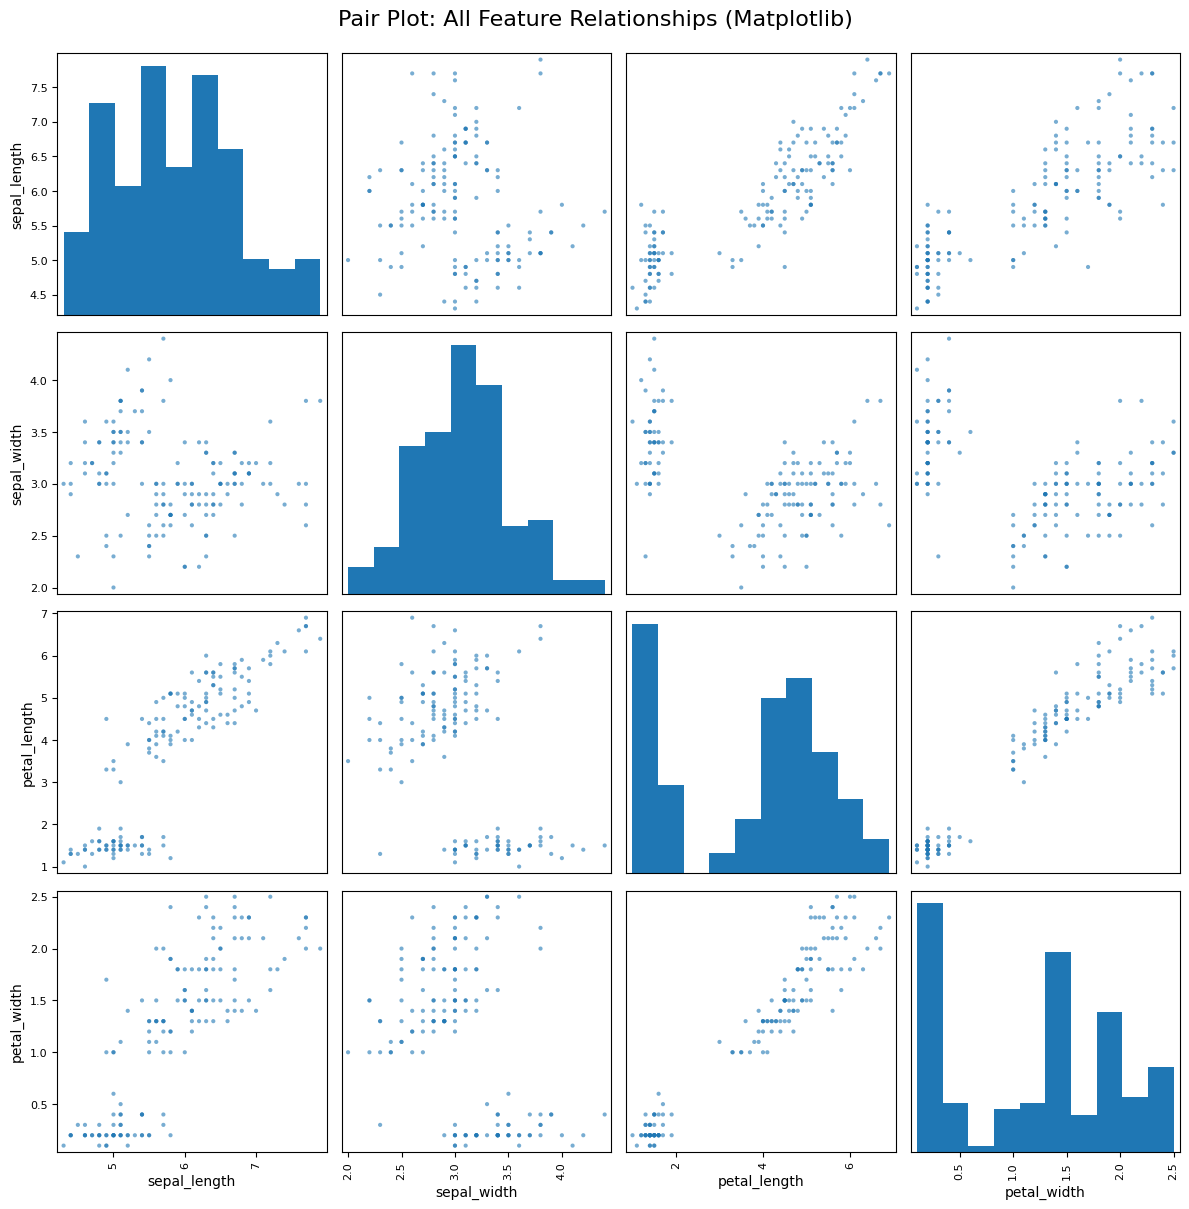

In [ ]:
# Pair plot using Pandas scatter_matrix
from pandas.plotting import scatter_matrix

fig, axes = plt.subplots(figsize=(12, 12))

# Create scatter matrix
scatter_matrix(iris.iloc[:, :4],  # Only numerical columns
               alpha=0.6,
               figsize=(12, 12),
               diagonal='hist',  # Histogram on diagonal
               ax=axes)

plt.suptitle('Pair Plot: All Feature Relationships (Matplotlib)',
             fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

**Observation:** We can see all 6 scatter plots + 4 histograms, but species are not color-coded.

### 6.2 — Pair Plot with Seaborn

Seaborn's `pairplot()` is much more powerful and easier to use!

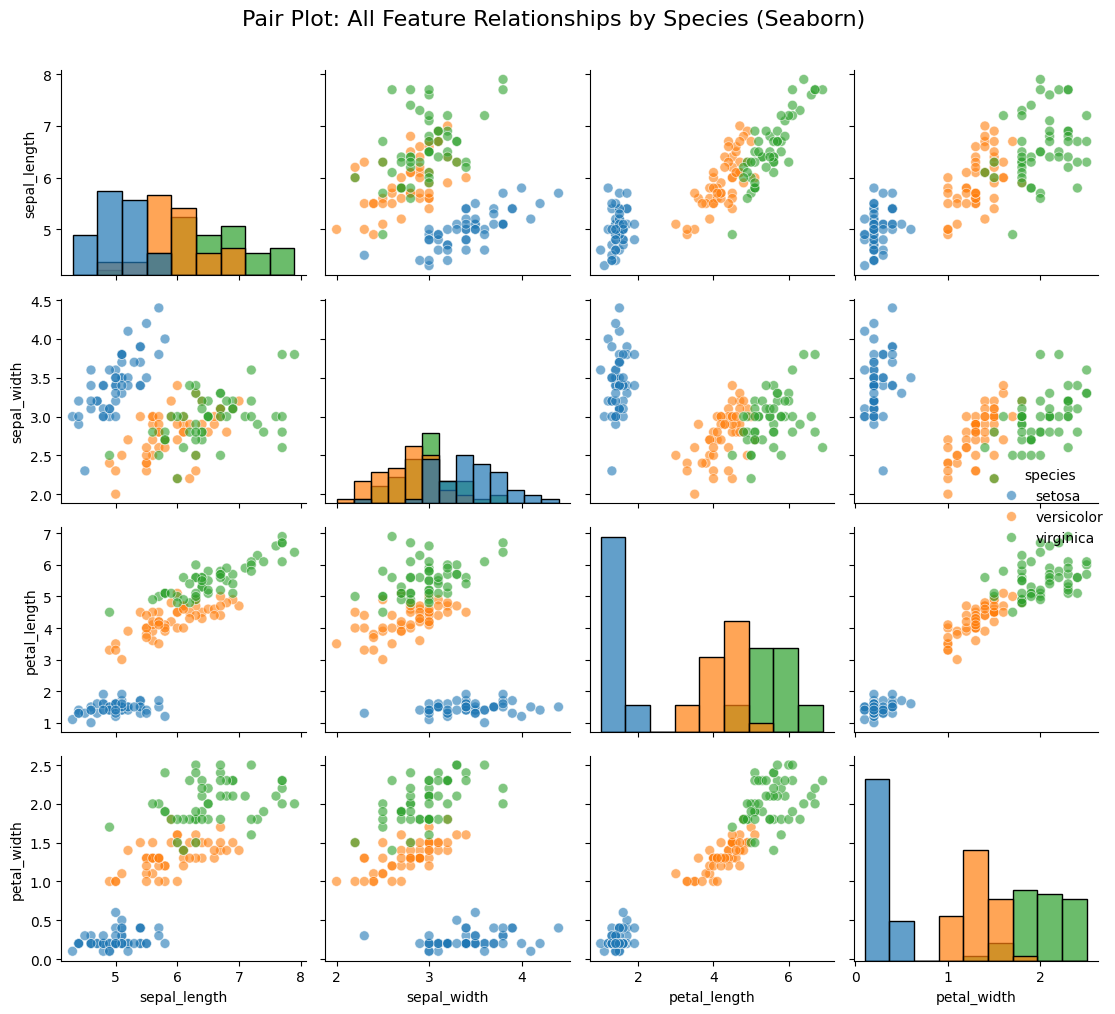

In [ ]:
# Pair plot using Seaborn
sns.pairplot(iris, hue='species', height=2.5, aspect=1,
             diag_kind='hist',  # or 'kde' for density plot
             plot_kws={'alpha': 0.6, 's': 50},
             diag_kws={'alpha': 0.7})

plt.suptitle('Pair Plot: All Feature Relationships by Species (Seaborn)',
             fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

**Seaborn advantages:**
- Automatic color coding by species
- Clean, professional styling
- Easy to customize
- Shows distributions on diagonal

**Key Observations:**
1. **Petal measurements** (bottom-right quadrant) show the best separation
2. **Setosa** is clearly separated in all plots
3. **Versicolor and Virginica** overlap in sepal measurements
4. **Strong correlation** between petal length and petal width

### 6.3 — Interactive Pair Plot with Plotly

Plotly's scatter matrix adds interactivity!

In [17]:
# Interactive pair plot using Plotly
fig = px.scatter_matrix(iris,
                        dimensions=['sepal_length', 'sepal_width',
                                    'petal_length', 'petal_width'],
                        color='species',
                        title='Interactive Pair Plot: All Feature Relationships',
                        labels={'sepal_length': 'Sepal L',
                                'sepal_width': 'Sepal W',
                                'petal_length': 'Petal L',
                                'petal_width': 'Petal W'},
                        height=800, width=900)

# Hide diagonal (optional)
fig.update_traces(diagonal_visible=False, showupperhalf=False)

fig.show()

**Plotly advantages:**
- **Hover** to see exact values
- **Zoom** into specific regions
- **Click legend** to filter species
- **Interactive exploration** of all relationships

**Try it:** Click on a species in the legend to hide/show it!

### Key Insights from Pair Plots

From our pair plot analysis, we discovered:

1. **Best Features for Classification:**
   - Petal length and petal width are the most discriminative
   - Sepal measurements alone are not sufficient

2. **Species Separation:**
   - Setosa: Completely separated (small petals)
   - Versicolor: Medium-sized, some overlap with Virginica
   - Virginica: Largest petals, some overlap with Versicolor

3. **Feature Correlations:**
   - Strong positive correlation: Petal length ↔ Petal width
   - Moderate correlation: Sepal length ↔ Petal measurements
   - Weak correlation: Sepal width ↔ Other features

4. **Distributions:**
   - Most features are approximately normally distributed
   - Petal measurements show bimodal distribution (two peaks)

---

## 7. Histograms — Understanding Distributions

### What is a Histogram?

A **histogram** shows the distribution of a single numerical variable by dividing the data into bins and counting how many observations fall into each bin.

**Think of it as:**
- A bar chart for continuous data
- A way to see the "shape" of your data
- A tool to identify patterns, outliers, and skewness

### How is a Histogram Built?

Let's understand step-by-step with an example:

**Example data:** [1.2, 1.5, 1.8, 2.1, 2.3, 2.5, 2.7, 3.0, 3.2, 3.5]

**Step 1: Choose the number of bins**
- Let's say we want 3 bins

**Step 2: Determine bin ranges**
- Min value: 1.2, Max value: 3.5
- Range: 3.5 - 1.2 = 2.3
- Bin width: 2.3 / 3 ≈ 0.77
- Bins: [1.2-1.97], [1.97-2.74], [2.74-3.5]

**Step 3: Count observations in each bin**
- Bin 1 [1.2-1.97]: 3 values (1.2, 1.5, 1.8)
- Bin 2 [1.97-2.74]: 4 values (2.1, 2.3, 2.5, 2.7)
- Bin 3 [2.74-3.5]: 3 values (3.0, 3.2, 3.5)

**Step 4: Draw bars**
- Height of each bar = count in that bin

```
Frequency
    4 |     ████
    3 | ████████████
    2 | ████████████
    1 | ████████████
    0 |____________
       1.2  1.97  2.74  3.5
           Value
```

**Key Parameters:**
- **bins:** Number of bins (more bins = more detail)
- **range:** Min and max values to include
- **density:** If True, shows probability density instead of count

### 7.1 — Basic Histogram (Matplotlib)

Let's create a histogram for sepal length.

In [18]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


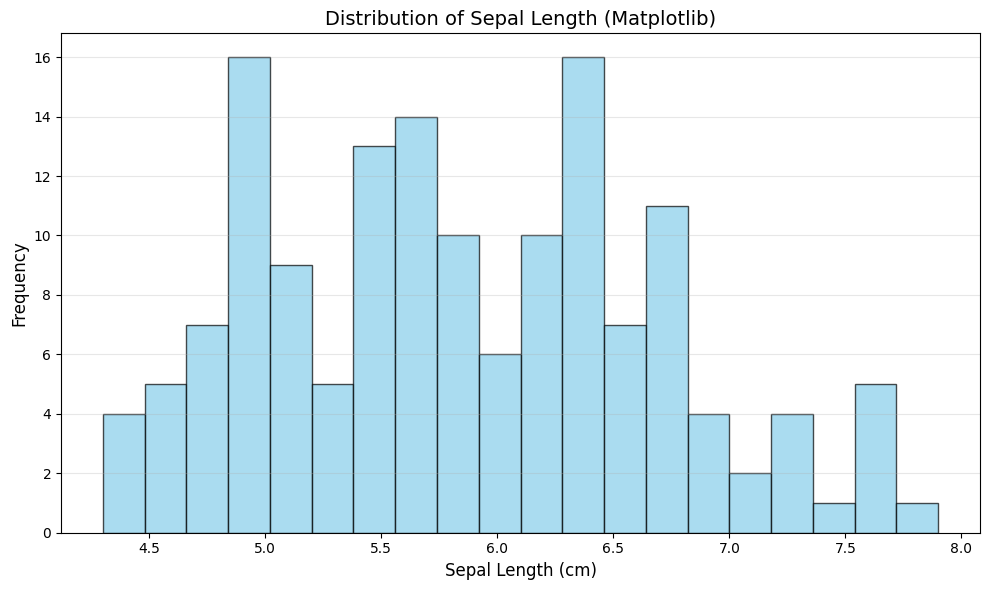

In [ ]:
# Basic histogram using Matplotlib
plt.figure(figsize=(10, 6))

plt.hist(iris['sepal_length'], bins=20, color='skyblue',
         edgecolor='black', alpha=0.7)

plt.xlabel('Sepal Length (cm)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Sepal Length (Matplotlib)', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:** The distribution looks roughly bell-shaped (normal distribution).

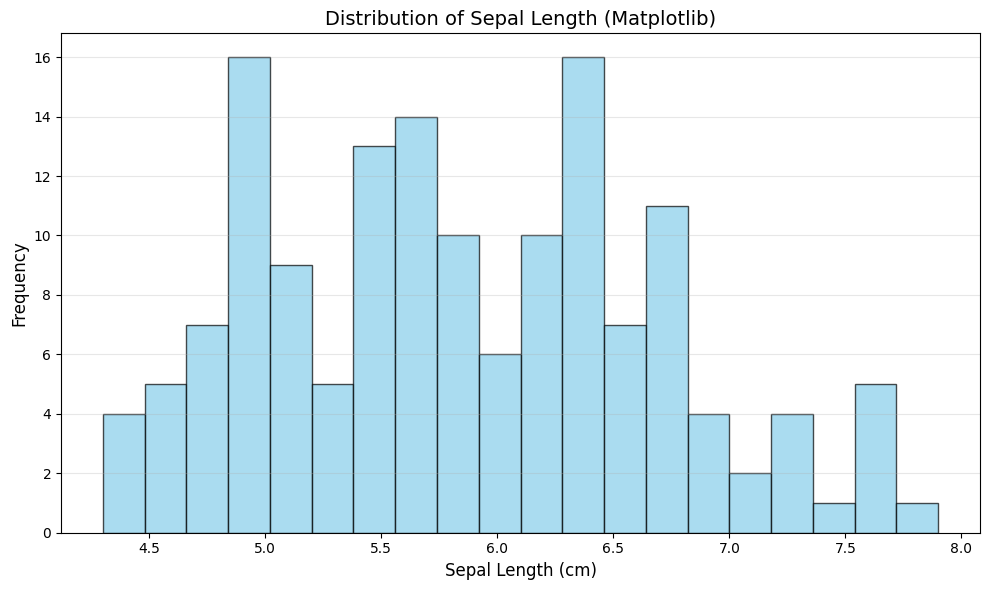

In [23]:
# Basic histogram using Matplotlib
plt.figure(figsize=(10, 6))

plt.hist(iris['sepal_length'], bins=20, color='skyblue',
         edgecolor='black', alpha=0.7)

plt.xlabel('Sepal Length (cm)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Sepal Length (Matplotlib)', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 7.2 — Histogram with Seaborn

Seaborn provides better styling and additional features.

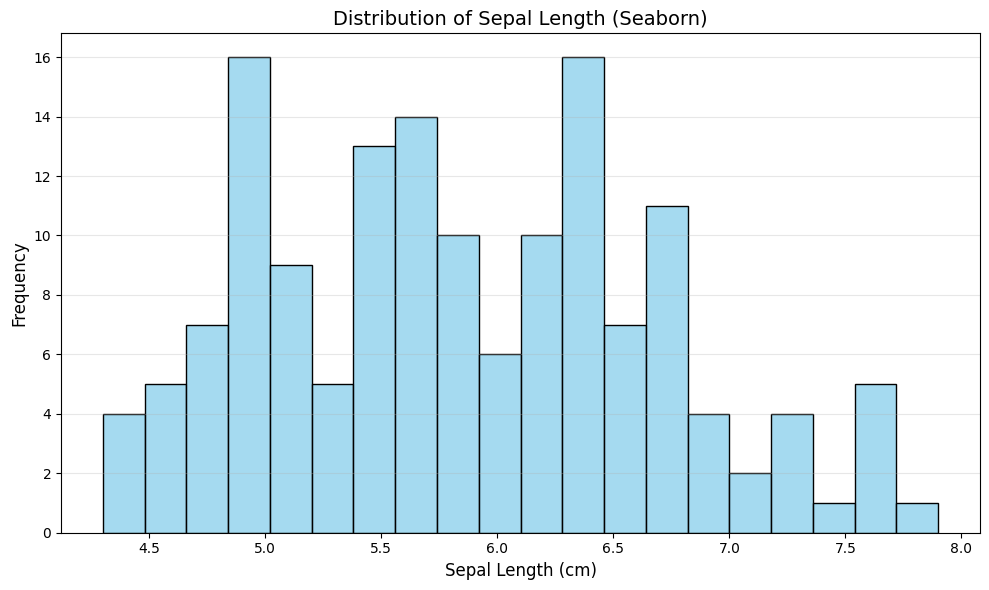

In [24]:
# Histogram using Seaborn
plt.figure(figsize=(10, 6))

sns.histplot(data=iris, x='sepal_length', bins=20,
             kde=False, color='skyblue', edgecolor='black')

plt.xlabel('Sepal Length (cm)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Sepal Length (Seaborn)', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 7.3 — Interactive Histogram with Plotly

In [25]:
# Interactive histogram using Plotly
fig = px.histogram(iris, x='sepal_length', nbins=20,
                   title='Distribution of Sepal Length (Plotly - Interactive)',
                   labels={'sepal_length': 'Sepal Length (cm)'},
                   color_discrete_sequence=['skyblue'])

fig.update_layout(xaxis_title='Sepal Length (cm)',
                  yaxis_title='Frequency',
                  showlegend=False)

fig.show()

**Try hovering** over the bars to see exact counts!

### 7.4 — Histogram Separated by Species

Now let's see how each species contributes to the overall distribution.

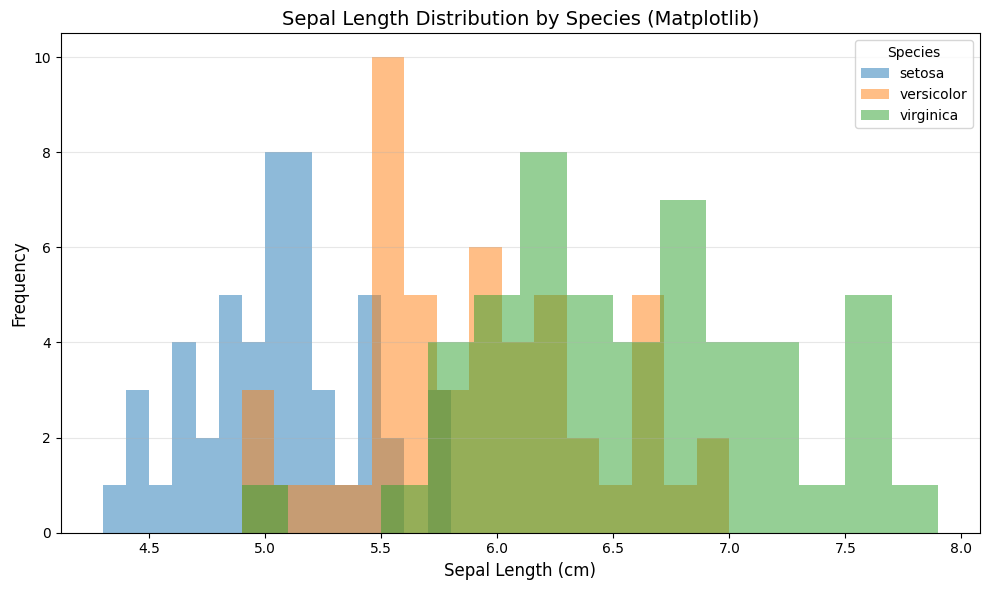

In [ ]:
# Overlapping histograms by species (Matplotlib)
plt.figure(figsize=(10, 6))

for species in iris['species'].unique():
    subset = iris[iris['species'] == species]
    plt.hist(subset['sepal_length'], bins=15, alpha=0.5, label=species)

plt.xlabel('Sepal Length (cm)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Sepal Length Distribution by Species (Matplotlib)', fontsize=14)
plt.legend(title='Species')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

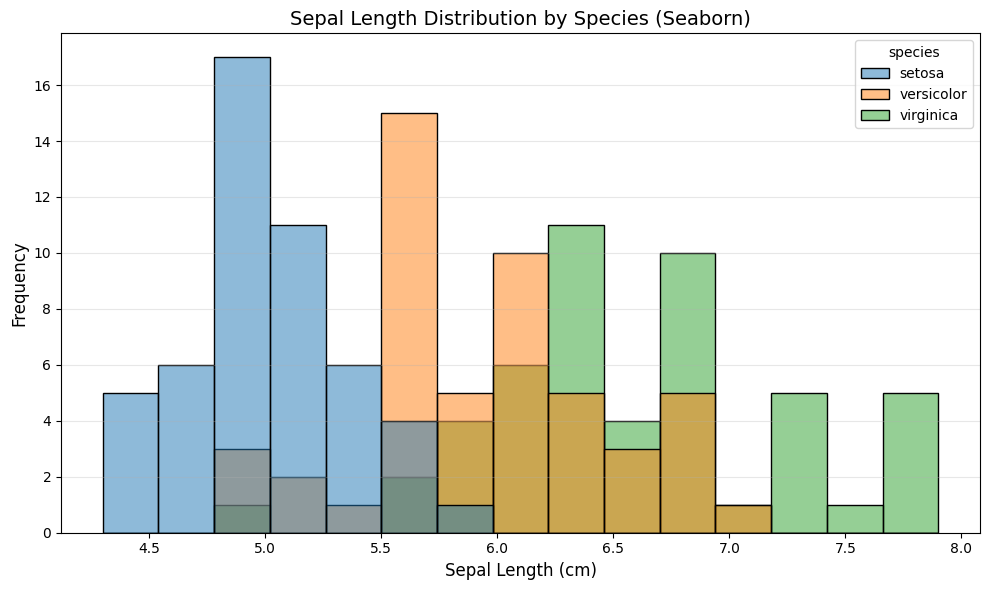

In [26]:
# Overlapping histograms by species (Seaborn)
plt.figure(figsize=(10, 6))

sns.histplot(data=iris, x='sepal_length', hue='species',
             bins=15, alpha=0.5, kde=False)

plt.xlabel('Sepal Length (cm)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Sepal Length Distribution by Species (Seaborn)', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

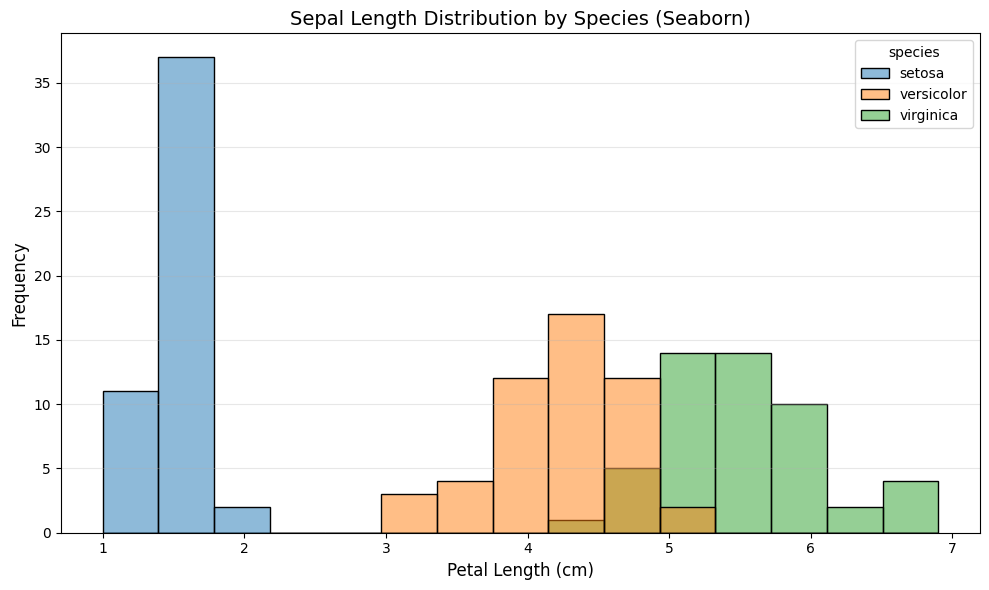

In [29]:
# Overlapping histograms by species (Seaborn)
plt.figure(figsize=(10, 6))

sns.histplot(data=iris, x='petal_length', hue='species',
             bins=15, alpha=0.5, kde=False)

plt.xlabel('Petal Length (cm)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Sepal Length Distribution by Species (Seaborn)', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
# Interactive overlapping histograms (Plotly)
fig = px.histogram(iris, x='petal_length', color='species',
                   nbins=15, barmode='overlay', opacity=0.6,
                   title='petal Length Distribution by Species (Plotly)',
                   labels={'petal_length': 'petal Length (cm)'})

fig.update_layout(xaxis_title='petal Length (cm)',
                  yaxis_title='Frequency')

fig.show()

**Observation:**
- Setosa has shorter sepals (peak around 5 cm)
- Versicolor and Virginica have longer sepals (peaks around 6-7 cm)
- There's overlap between all three species

### 7.5 — Histogram with PDF (Probability Density Function)

A **PDF curve** (also called KDE - Kernel Density Estimate) shows a smooth estimate of the distribution.

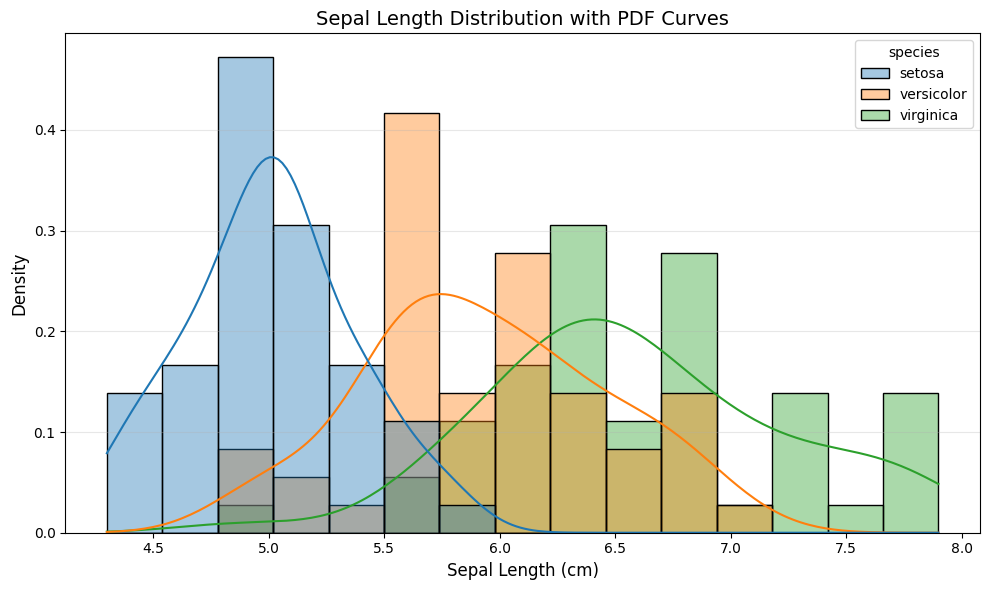

In [ ]:
# Histogram with PDF curve (Seaborn)
plt.figure(figsize=(10, 6))

sns.histplot(data=iris, x='sepal_length', hue='species',
             bins=15, alpha=0.4, kde=True, stat='density')

plt.xlabel('Sepal Length (cm)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Sepal Length Distribution with PDF Curves', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**What is the PDF curve?**
- The smooth line over the histogram
- Shows the probability density at each value
- Area under the curve = 1 (100% probability)
- Helps identify the shape of the distribution

**Observation:** The PDF curves clearly show the different distributions for each species.

### 7.6 — Histograms for All Features

Let's create histograms for all 4 features to see how they differ.

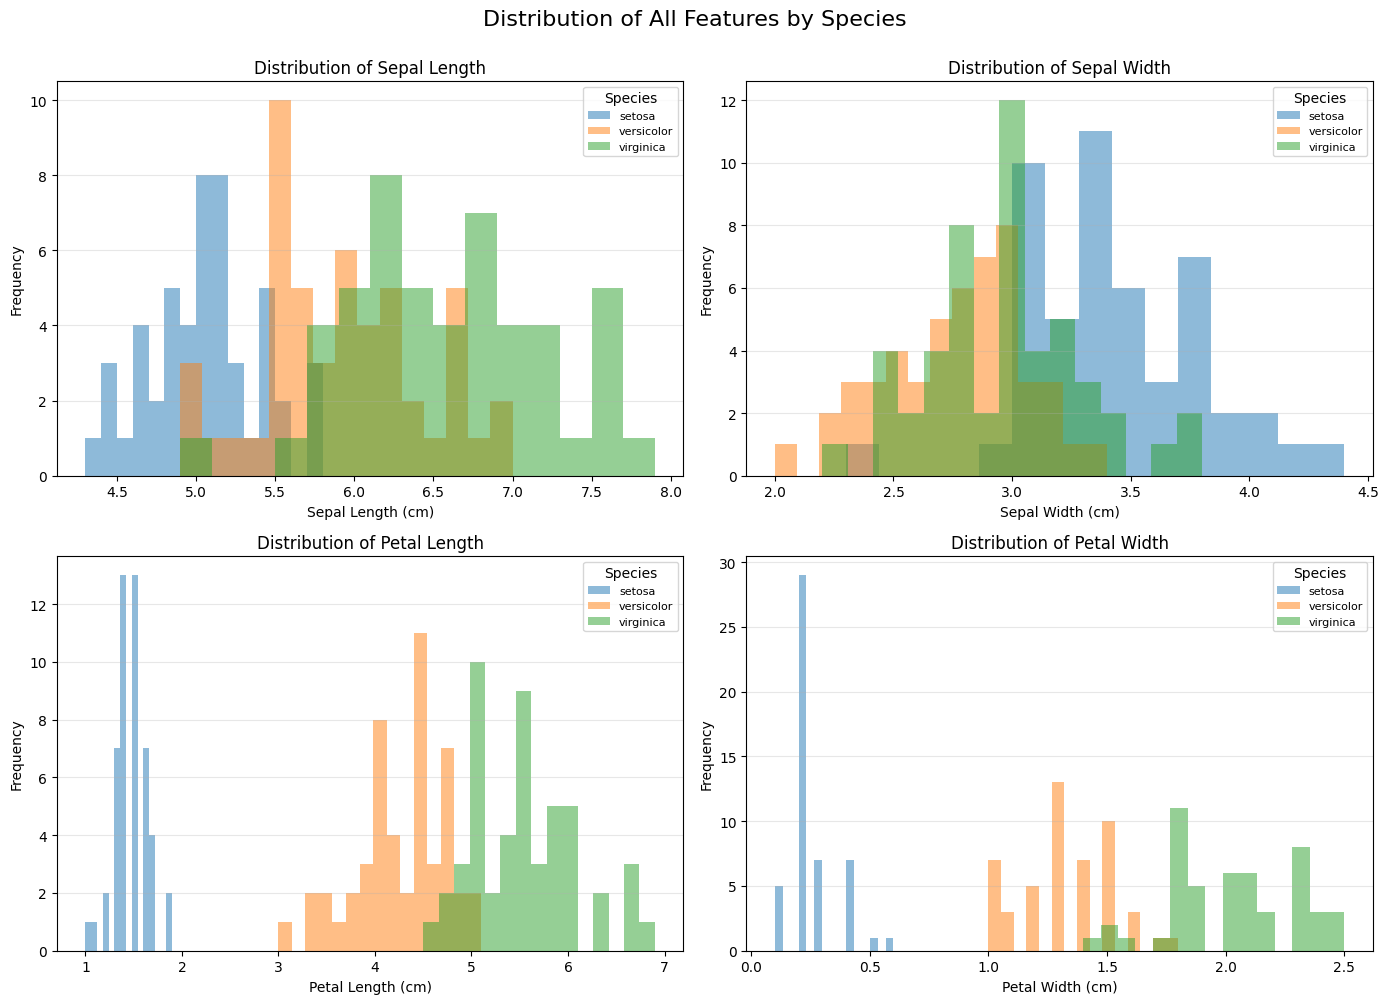

In [ ]:
# Histograms for all features (Matplotlib)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
titles = ['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width']

for ax, feature, title in zip(axes.flat, features, titles):
    for species in iris['species'].unique():
        subset = iris[iris['species'] == species]
        ax.hist(subset[feature], bins=15, alpha=0.5, label=species)

    ax.set_xlabel(f'{title} (cm)', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.set_title(f'Distribution of {title}', fontsize=12)
    ax.legend(title='Species', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Distribution of All Features by Species', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

**Key Observations:**

1. **Sepal Length:**
   - Setosa: Shorter (4.5-5.5 cm)
   - Versicolor & Virginica: Longer (5.5-7.5 cm)
   - Significant overlap

2. **Sepal Width:**
   - Setosa: Wider (3.0-4.0 cm)
   - Versicolor & Virginica: Narrower (2.0-3.5 cm)
   - Most overlap among all features

3. **Petal Length:**
   - Setosa: Very short (1.0-2.0 cm) - CLEARLY SEPARATED!
   - Versicolor: Medium (3.0-5.0 cm)
   - Virginica: Long (4.5-7.0 cm)
   - Best feature for classification

4. **Petal Width:**
   - Setosa: Very narrow (0.1-0.5 cm) - CLEARLY SEPARATED!
   - Versicolor: Medium (1.0-1.5 cm)
   - Virginica: Wide (1.5-2.5 cm)
   - Second best feature for classification

**Conclusion:** Petal measurements are much more discriminative than sepal measurements!

### Impact of Feature Choice

**Why does this matter?**

If you were building a machine learning model to classify iris species:

**Using only Sepal measurements:**
- Accuracy: ~70-80% (lots of overlap)
- Difficult to distinguish Versicolor from Virginica

**Using only Petal measurements:**
- Accuracy: ~95-98% (clear separation)
- Easy to distinguish all three species

**Using all 4 features:**
- Accuracy: ~97-99% (best performance)
- Combines information from all measurements

**Lesson:** Feature selection matters! Some features are more informative than others.

---

## 8. Box Plots — Statistical Summaries

### What is a Box Plot?

A **box plot** (also called box-and-whisker plot) is a standardized way of displaying the distribution of data based on five key statistics:

1. **Minimum** (excluding outliers)
2. **Q1 (First Quartile)** - 25th percentile
3. **Median (Q2)** - 50th percentile
4. **Q3 (Third Quartile)** - 75th percentile
5. **Maximum** (excluding outliers)
6. **Outliers** - Points beyond the whiskers

### Anatomy of a Box Plot

```
                    Maximum (excluding outliers)
                         ┬
                         │  ← Upper whisker
                         │
                    ┌────┴────┐
                    │    Q3   │  ← 75th percentile (top of box)
                    ├─────────┤
                    │ Median  │  ← 50th percentile (line in middle)
                    ├─────────┤
                    │    Q1   │  ← 25th percentile (bottom of box)
                    └────┬────┘
                         │  ← Lower whisker
                         │
                         ┴
                    Minimum (excluding outliers)

                    ●  ← Outliers (individual points)
```

**Key Components:**

- **Box:** Contains the middle 50% of data (Q1 to Q3)
- **Line in box:** Median (middle value)
- **Whiskers:** Extend to min/max within 1.5 × IQR
- **Dots:** Outliers beyond whiskers

### What is IQR (Interquartile Range)?

**IQR** is a measure of statistical dispersion (spread) of the data.

**Formula:** IQR = Q3 - Q1

**What it represents:**
- The range of the middle 50% of the data
- The "box" in the box plot
- A robust measure of spread (not affected by outliers)

**Example:**
- Q1 = 5.0 cm
- Q3 = 6.5 cm
- IQR = 6.5 - 5.0 = 1.5 cm

**Outlier Detection:**
- **Lower outliers:** Values < Q1 - 1.5 × IQR
- **Upper outliers:** Values > Q3 + 1.5 × IQR

**Why 1.5 × IQR?**
- It's a convention that works well in practice
- Captures ~99.3% of data if normally distributed
- Balances between being too strict and too lenient

### 8.1 — Basic Box Plot (Matplotlib)

Let's create a box plot for sepal length by species.

/tmp/ipykernel_608/348571287.py:8: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



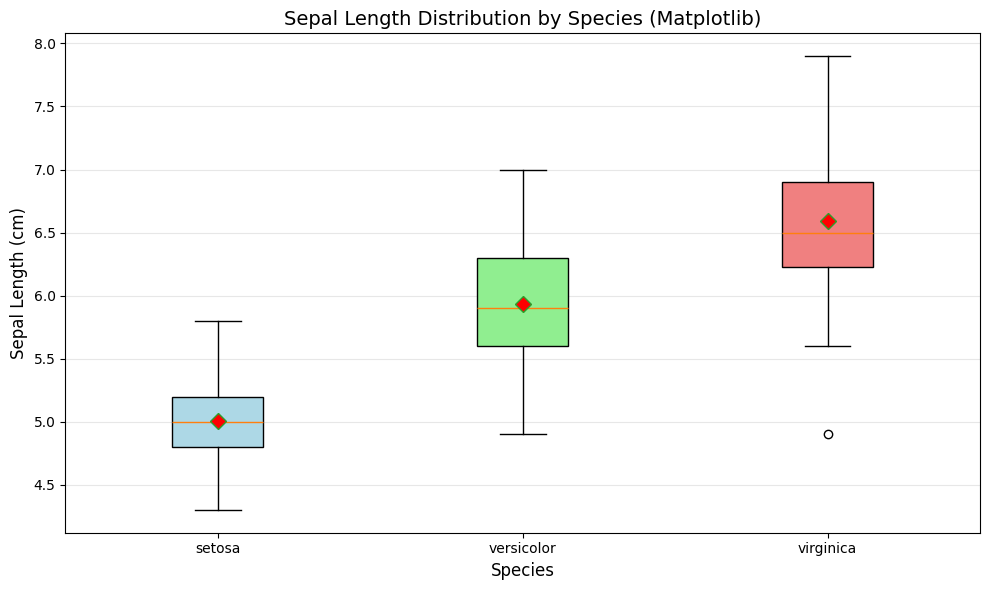

In [33]:
# Basic box plot using Matplotlib
plt.figure(figsize=(10, 6))

# Prepare data for each species
data_to_plot = [iris[iris['species'] == species]['sepal_length']
                for species in iris['species'].unique()]

bp = plt.boxplot(data_to_plot,
                 labels=iris['species'].unique(),
                 patch_artist=True,  # Fill boxes with color
                 showmeans=True,     # Show mean as a point
                 meanprops=dict(marker='D', markerfacecolor='red', markersize=8))

# Color the boxes
colors = ['lightblue', 'lightgreen', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

plt.xlabel('Species', fontsize=12)
plt.ylabel('Sepal Length (cm)', fontsize=12)
plt.title('Sepal Length Distribution by Species (Matplotlib)', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:**
- Setosa has the shortest sepal length (median ~5.0 cm)
- Virginica has the longest sepal length (median ~6.5 cm)
- Versicolor is in between (median ~5.9 cm)
- Red diamonds show the mean values

### 8.2 — Box Plot with Seaborn

Seaborn makes it easier and adds better styling.

/tmp/ipykernel_608/3251449436.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




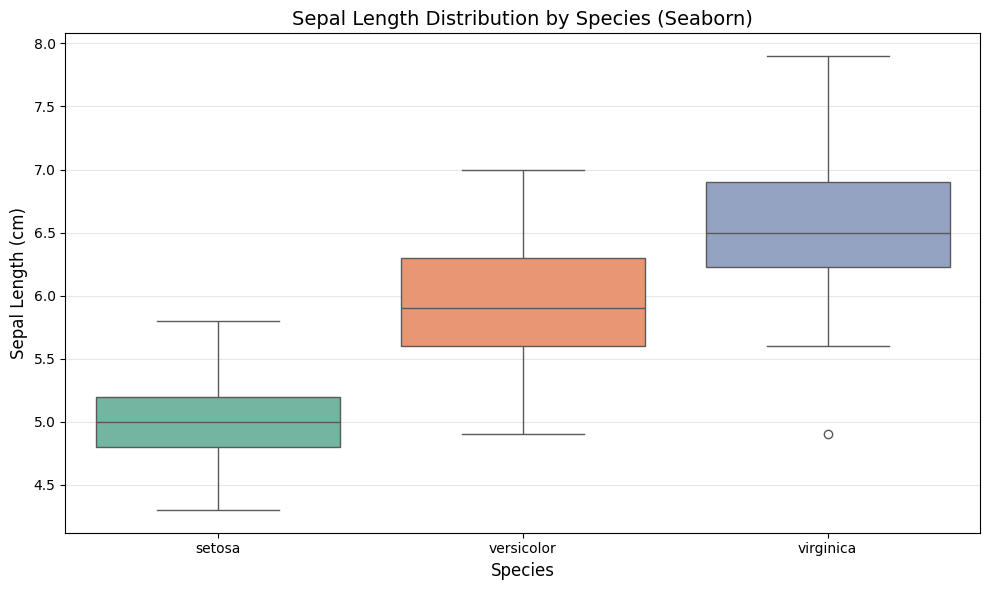

In [34]:
# Box plot using Seaborn
plt.figure(figsize=(10, 6))

sns.boxplot(data=iris, x='species', y='sepal_length', palette='Set2')

plt.xlabel('Species', fontsize=12)
plt.ylabel('Sepal Length (cm)', fontsize=12)
plt.title('Sepal Length Distribution by Species (Seaborn)', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 8.3 — Interactive Box Plot with Plotly

In [35]:
# Interactive box plot using Plotly
fig = px.box(iris, x='species', y='sepal_length', color='species',
             title='Sepal Length Distribution by Species (Plotly - Interactive)',
             labels={'sepal_length': 'Sepal Length (cm)', 'species': 'Species'},
             points='all')  # Show all data points

fig.update_layout(showlegend=False)
fig.show()

**Plotly advantages:**
- **Hover** over box to see Q1, median, Q3, min, max
- **Hover** over points to see exact values
- **See all individual data points** overlaid on the box
- **Interactive exploration** of outliers

### 8.4 — Box Plots for All Features

Let's compare all 4 features side by side.

/tmp/ipykernel_608/1411272691.py:11: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.

/tmp/ipykernel_608/1411272691.py:11: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.

/tmp/ipykernel_608/1411272691.py:11: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.

/tmp/ipykernel_608/1411272691.py:11: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



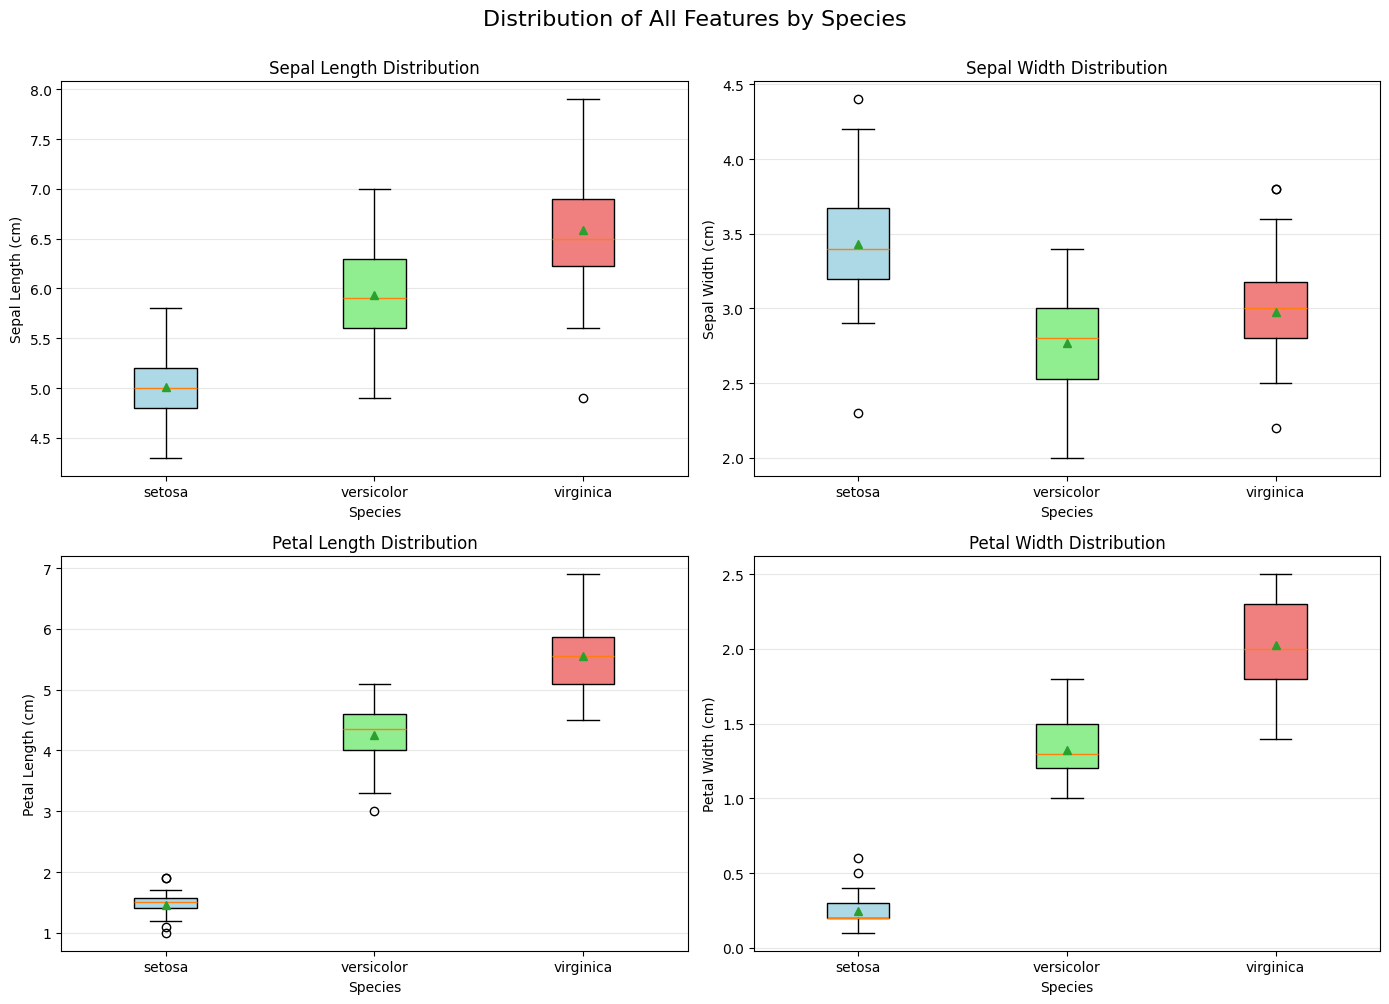

In [36]:
# Box plots for all features (Matplotlib)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
titles = ['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width']

for ax, feature, title in zip(axes.flat, features, titles):
    data_to_plot = [iris[iris['species'] == species][feature]
                    for species in iris['species'].unique()]

    bp = ax.boxplot(data_to_plot, labels=iris['species'].unique(),
                    patch_artist=True, showmeans=True)

    colors = ['lightblue', 'lightgreen', 'lightcoral']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

    ax.set_xlabel('Species', fontsize=10)
    ax.set_ylabel(f'{title} (cm)', fontsize=10)
    ax.set_title(f'{title} Distribution', fontsize=12)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Distribution of All Features by Species', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

**Key Observations:**

1. **Sepal Length:**
   - Clear progression: Setosa < Versicolor < Virginica
   - Some overlap between species
   - Few outliers

2. **Sepal Width:**
   - Setosa has wider sepals than others
   - Versicolor and Virginica very similar
   - Several outliers in all species

3. **Petal Length:**
   - **BEST SEPARATION!** No overlap between Setosa and others
   - Setosa: Very short petals (1-2 cm)
   - Clear distinction between all three species
   - Minimal outliers

4. **Petal Width:**
   - **SECOND BEST!** Clear separation
   - Setosa: Very narrow petals (0.1-0.5 cm)
   - Good distinction between species
   - Few outliers

### 8.5 — Violin Plots (Box Plot + Distribution)

A **violin plot** combines a box plot with a kernel density plot, showing both the summary statistics and the shape of the distribution.

/tmp/ipykernel_608/2063983758.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




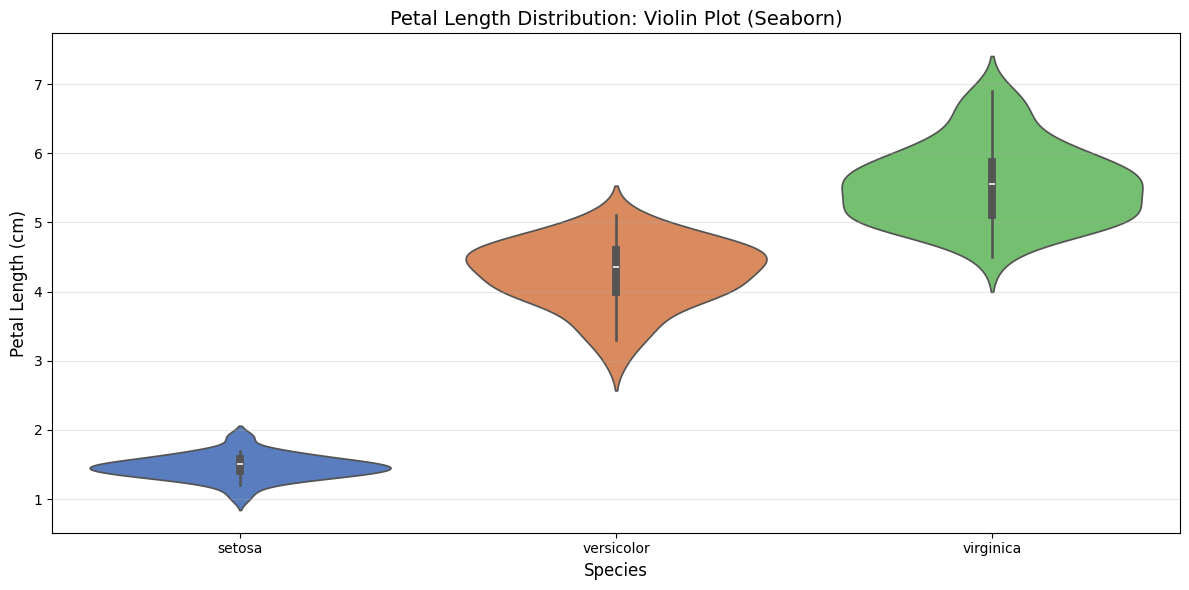

In [37]:
# Violin plot using Seaborn
plt.figure(figsize=(12, 6))

sns.violinplot(data=iris, x='species', y='petal_length', palette='muted')

plt.xlabel('Species', fontsize=12)
plt.ylabel('Petal Length (cm)', fontsize=12)
plt.title('Petal Length Distribution: Violin Plot (Seaborn)', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

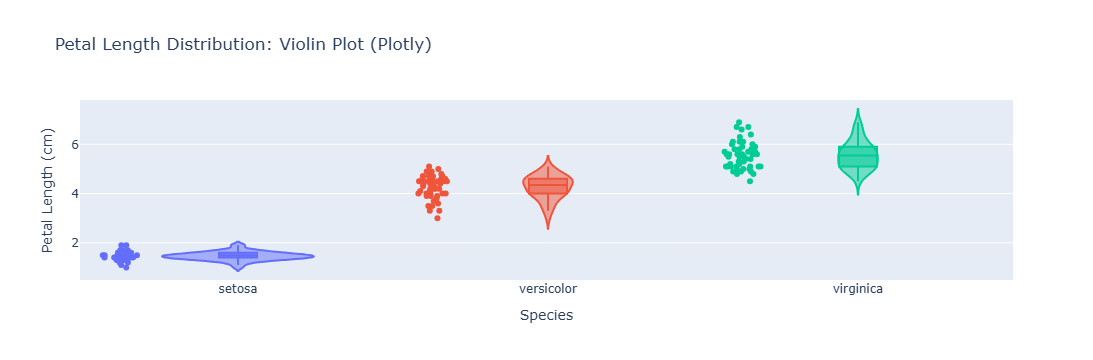

In [ ]:
# Interactive violin plot using Plotly
fig = px.violin(iris, x='species', y='petal_length', color='species',
                box=True,  # Show box plot inside
                points='all',  # Show all points
                title='Petal Length Distribution: Violin Plot (Plotly)',
                labels={'petal_length': 'Petal Length (cm)', 'species': 'Species'})

fig.update_layout(showlegend=False)
fig.show()

**Violin plot advantages:**
- Shows the **full distribution shape** (not just summary statistics)
- Reveals **bimodal** or **multimodal** distributions
- Combines **box plot** (inside) with **density plot** (outside)
- More informative than box plots alone

**Observation:**
- Setosa has a narrow, concentrated distribution (all flowers very similar)
- Versicolor has a wider distribution (more variability)
- Virginica has the widest distribution (most variability)

### 8.6 — Understanding IQR with Real Data

Let's calculate IQR for petal length of Setosa.

In [ ]:
# Calculate IQR for Setosa petal length
setosa_petal = iris[iris['species'] == 'setosa']['petal_length']

Q1 = setosa_petal.quantile(0.25)
Q2 = setosa_petal.quantile(0.50)  # Median
Q3 = setosa_petal.quantile(0.75)
IQR = Q3 - Q1

# Outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find outliers
outliers = setosa_petal[(setosa_petal < lower_bound) | (setosa_petal > upper_bound)]

print("Setosa Petal Length Statistics:")
print(f"Q1 (25th percentile): {Q1:.2f} cm")
print(f"Q2 (Median): {Q2:.2f} cm")
print(f"Q3 (75th percentile): {Q3:.2f} cm")
print(f"IQR: {IQR:.2f} cm")
print(f"\nOutlier boundaries:")
print(f"Lower bound: {lower_bound:.2f} cm")
print(f"Upper bound: {upper_bound:.2f} cm")
print(f"\nNumber of outliers: {len(outliers)}")
if len(outliers) > 0:
    print(f"Outlier values: {outliers.values}")

Setosa Petal Length Statistics:
Q1 (25th percentile): 1.40 cm
Q2 (Median): 1.50 cm
Q3 (75th percentile): 1.58 cm
IQR: 0.18 cm

Outlier boundaries:
Lower bound: 1.14 cm
Upper bound: 1.84 cm

Number of outliers: 4
Outlier values: [1.1 1.  1.9 1.9]


**Interpretation:**
- The middle 50% of Setosa petal lengths fall within the IQR
- Any value below the lower bound or above the upper bound is considered an outlier
- Outliers are unusual but not necessarily errors - they're just extreme values

---

## Summary

### What We Learned

1. **Basic Terminology**
   - EDA, features, variables, observations
   - Input vs output variables
   - Understanding dimensions (1D, 2D, 3D, nD)

2. **Data Exploration**
   - Loading data with Pandas
   - Basic methods: head(), tail(), shape, info(), describe()
   - Checking for missing values
   - Understanding data types

3. **2D Scatter Plots**
   - Visualizing relationships between two features
   - Comparing Pandas, Matplotlib, Seaborn, and Plotly
   - Color-coding by species

4. **3D Scatter Plots**
   - Visualizing three features simultaneously
   - Techniques for 4D+ visualization
   - Interactive rotation and exploration

5. **Pair Plots**
   - Viewing all feature relationships at once
   - Calculating combinations: C(n, 2)
   - Identifying best features for classification

6. **Histograms**
   - Understanding distributions
   - How histograms are built
   - PDF curves (KDE)
   - Comparing distributions across species

7. **Box Plots**
   - Statistical summaries (Q1, median, Q3)
   - Understanding IQR
   - Detecting outliers
   - Violin plots for richer information

### Key Insights from Iris Dataset

1. **Best Features:** Petal length and petal width are most discriminative
2. **Species Separation:** Setosa is clearly separated; Versicolor and Virginica overlap
3. **Correlations:** Strong positive correlation between petal length and width
4. **Distributions:** Most features are approximately normal; petal measurements show bimodal patterns

### Next Steps

- Apply these techniques to your own datasets
- Experiment with different visualizations
- Practice interpreting plots
- Learn about correlation analysis and statistical tests

---

*Happy exploring! 📊🔍*

In [ ]:
import pandas as pd
import xml.etree.ElementTree as ET

def svg_to_iris_df(svg_path):

    # Parse SVG
    tree = ET.parse(svg_path)
    root = tree.getroot()

    # Namespace handling
    namespace = {'svg': 'http://www.w3.org/2000/svg'}

    # Extract text elements
    texts = []
    for text in root.findall('.//svg:text', namespace):
        x = float(text.attrib.get('x', 0))
        y = float(text.attrib.get('y', 0))
        value = text.text.strip()
        texts.append((x, y, value))

    # Convert to dataframe
    df_text = pd.DataFrame(texts, columns=['x', 'y', 'value'])

    # Remove header row
    header_y = df_text['y'].min()
    df_text = df_text[df_text['y'] > header_y]

    # Group rows by y coordinate
    df_text['row'] = df_text['y'].rank(method='dense').astype(int)

    # Sort columns by x
    df_text = df_text.sort_values(['row', 'x'])

    # Pivot into table
    iris_df = df_text.groupby('row')['value'].apply(list).apply(pd.Series)

    iris_df.columns = [
        'sepal_length',
        'sepal_width',
        'petal_length',
        'petal_width',
        'species'
    ]

    # Convert numeric columns
    for col in iris_df.columns[:-1]:
        iris_df[col] = iris_df[col].astype(float)

    return iris_df